## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Load Data

In [2]:
df = pd.read_csv('C:/Users/Acer/Downloads/StudentPerformanceFactors.csv')
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Replace missing values ​​with Mode

In [3]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [4]:
print(df.Teacher_Quality.value_counts(dropna=False))
print(df.Parental_Education_Level.value_counts(dropna=False))
print(df.Distance_from_Home.value_counts(dropna=False))

Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
NaN               90
Name: count, dtype: int64
Distance_from_Home
Near        3884
Moderate    1998
Far          658
NaN           67
Name: count, dtype: int64


In [5]:
cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
df.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## scatter plot Hours_Studied and Exam_Score

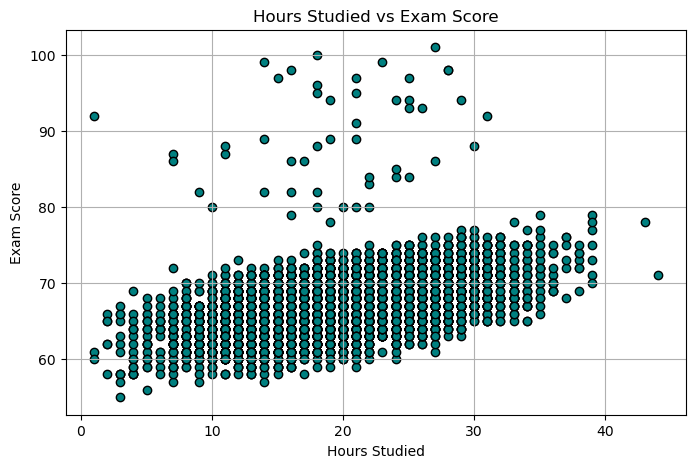

In [7]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='teal', edgecolor='black')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

In [8]:
df['Hours_Studied'].corr(df['Exam_Score'])


0.44545495407528174

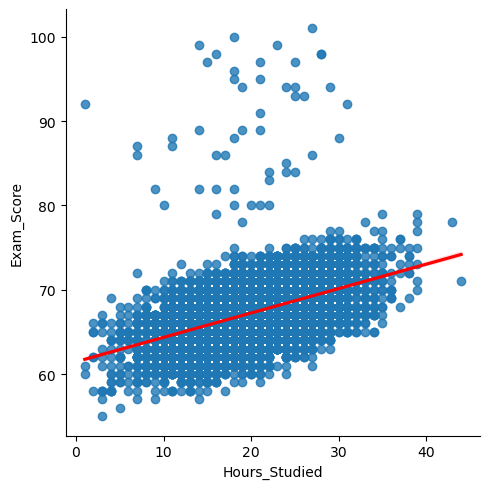

In [9]:
sns.lmplot(x='Hours_Studied', y='Exam_Score', data=df, line_kws={'color': 'red'})

### There's a weak correlation here.
For example, there's a student who studied for only one hour, but their score is somewhere around 93.
Overall, there's a correlation, but there's also a small cluster (about 40-50 students) of scores between 80 and 100, and these are students who studied between 10 and 30 hours. And what's most interesting is that after 30 hours, the maximum score doesn't even reach 80.

### The graph also shows outliers.
For example, a student who studied for only one hour scored a 93. This is an outlier, or they must be very smart to grasp all the information in one hour.
Another outlier is a student who studied for 45 hours but scored less than 70, or they are a very weak student.

## scatter plot Attendance and Exam_Score

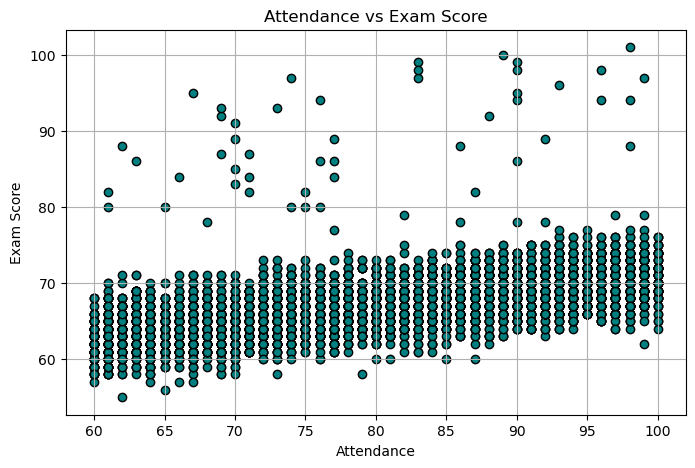

In [10]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Attendance'], df['Exam_Score'], color='teal', edgecolor='black')
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

In [11]:
df['Attendance'].corr(df['Exam_Score'])


0.5810718633120638

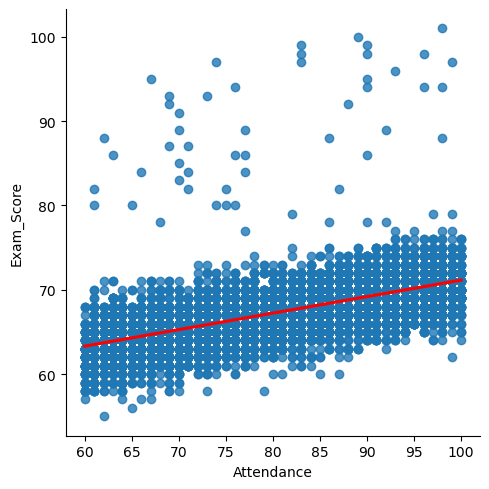

In [12]:
sns.lmplot(x='Attendance', y='Exam_Score', data=df, line_kws={'color': 'red'})

### Weak to Moderate Positive Correlation:

While there's a slight upward trend, it’s not very strong or linear.

Students with higher attendance tend to get better scores, but it’s not guaranteed.

### Wide Score Variability at Every Attendance Level:

Even students with ~100% attendance can score as low as 60 or as high as 100.

This suggests that attendance alone does not determine performance.

### Outliers:

A few students with lower attendance (~60–70%) have still scored very well (90+).

These could be gifted students, or perhaps they had external help like tutoring.

In [13]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


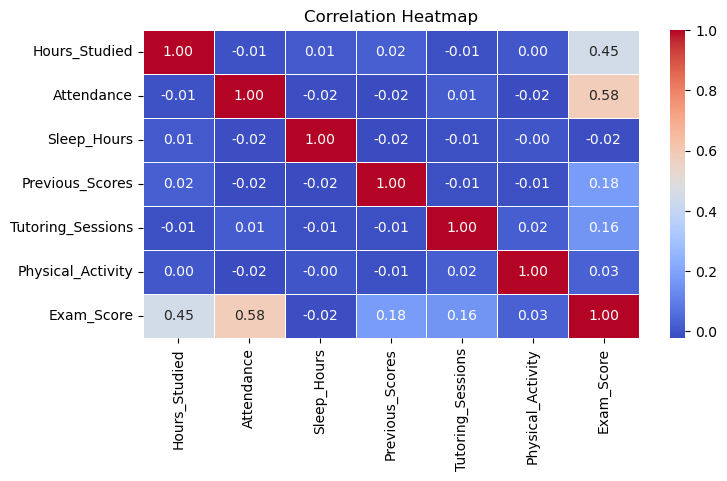

In [14]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Encoding Categorical features

In [15]:
# Use LabelEncoding for ordinal features
le = LabelEncoder()
ordinal_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
    'Family_Income', 'Teacher_Quality', 'Peer_Influence',
    'Parental_Education_Level', 'Distance_from_Home'
]

for col in ordinal_cols:
    df[col] = le.fit_transform(df[col])
    

In [16]:
# Use One-Hot Encoding for binary features
binary_cols = ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender']
df = pd.get_dummies(df, columns=binary_cols, drop_first=True)

In [17]:
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
0,23,84,1,0,7,73,1,0,1,2,2,3,1,2,67,False,True,True,False,True
1,19,64,1,2,8,59,1,2,2,2,0,4,0,1,61,False,True,True,False,False
2,24,98,2,2,7,91,2,2,2,2,1,4,2,2,74,True,True,True,False,True
3,29,89,1,2,8,98,2,1,2,2,0,4,1,1,71,True,True,True,False,True
4,19,92,2,2,6,65,2,3,2,0,1,4,0,2,70,True,True,True,False,False


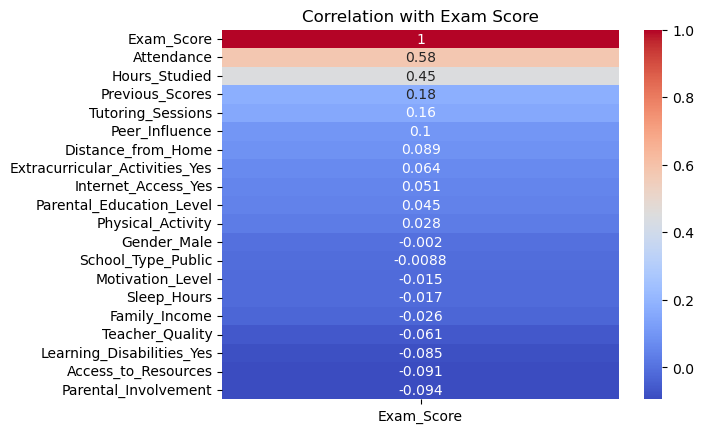

In [18]:
# Correlation with Target variable
corr = df.corr(numeric_only=True)  # Only numeric columns
sns.heatmap(corr[['Exam_Score']].sort_values(by='Exam_Score', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Exam Score')
plt.show()

In [19]:
# Convert boolean columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [20]:
df.shape

(6607, 20)

## Modeling

In [21]:
# Define features and target
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

In [22]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = lr.predict(X_test)

In [25]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.0155490830845963
MSE: 4.399275539170951
R2 Score: 0.6887688020307758


In [26]:
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
0,23,84,1,0,7,73,1,0,1,2,2,3,1,2,67,0,1,1,0,1
1,19,64,1,2,8,59,1,2,2,2,0,4,0,1,61,0,1,1,0,0
2,24,98,2,2,7,91,2,2,2,2,1,4,2,2,74,1,1,1,0,1
3,29,89,1,2,8,98,2,1,2,2,0,4,1,1,71,1,1,1,0,1
4,19,92,2,2,6,65,2,3,2,0,1,4,0,2,70,1,1,1,0,0


The linear regression model provided a reasonable baseline for predicting student exam scores, with an R² score of 0.69. This suggests that approximately 69% of the variation in exam scores can be explained by the features in the dataset. The MAE of 1.02 indicates that the average prediction error is just over 1 point, which may be acceptable depending on the use case.

However, the model assumes linear relationships between features and the target, which may not fully capture the complexity of student performance influenced by various factors like motivation, parental involvement, and resource access. Therefore, exploring non-linear models may lead to improved predictive accuracy.

## Random Forest

In [27]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
y_pred_rf = rf.predict(X_test)

In [30]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 1.1315431164901666
MSE: 4.868488502269289
R2 Score: 0.65557385633858


The Random Forest Regressor did not outperform the baseline Linear Regression model. With a slightly higher MAE and MSE, and a lower R² score (0.66 vs. 0.69), it appears that the Random Forest model may be overfitting or unable to generalize well to this dataset in its default configuration.

These results suggest that the relationships in the data might be more linear than expected, or that Random Forest needs hyperparameter tuning to improve its performance. Linear Regression, while simpler, may be more aligned with the structure of the dataset.

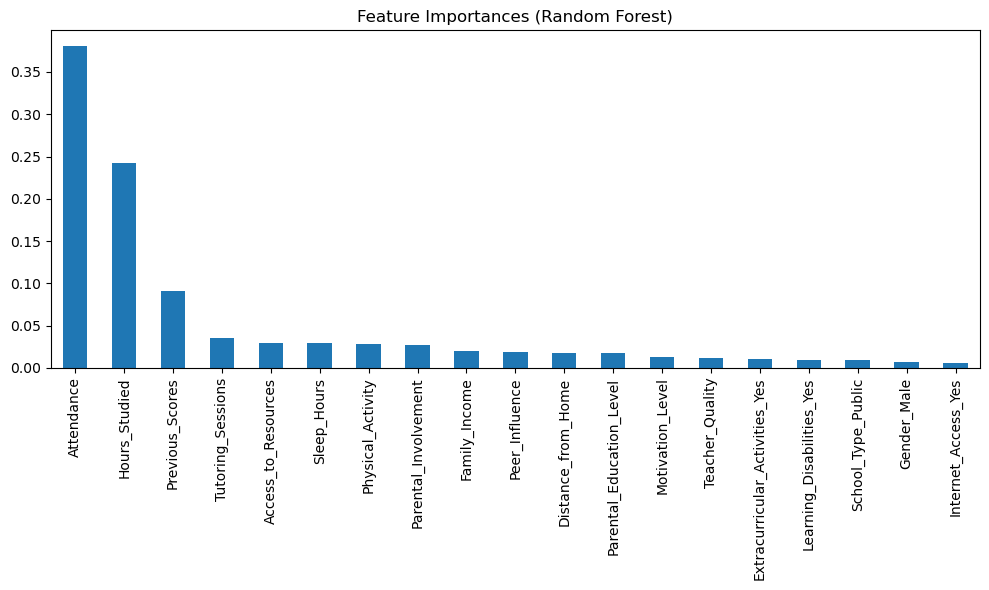

In [31]:
# Feature importance
importances = rf.feature_importances_
feature_names = X.columns

# Sort by importance
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
feat_importance.plot(kind='bar')
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


## XGBost

In [32]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    objective='reg:squarederror'
)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
y_pred_xgb = xgb.predict(X_test)

In [34]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 0.7690902138622012
MSE: 3.7375352929980448
R2 Score: 0.7355842590332031


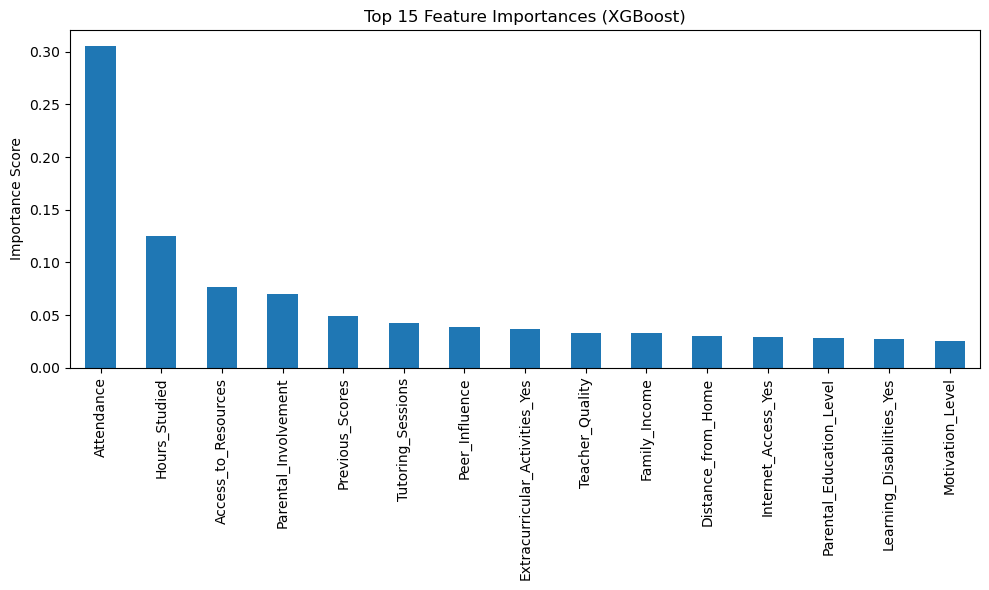

In [35]:
# Get feature importances from XGBoost
importances = xgb.feature_importances_
feature_names = X.columns

# Create a Series and sort
feat_imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
feat_imp_series.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

## Tune Hyperparameters in XGBoost

In [36]:
# Define base model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid of parameters to try
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Run grid search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

# Fit
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Evaluate
y_pred_gs = best_model.predict(X_test)
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_gs))
print("Tuned MSE:", mean_squared_error(y_test, y_pred_gs))
print("Tuned R2 Score:", r2_score(y_test, y_pred_gs))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Tuned MAE: 0.6708817128514739
Tuned MSE: 3.5225942925183142
Tuned R2 Score: 0.7507904767990112


After hyperparameter tuning using Grid Search, the XGBoost Regressor achieved its best performance with an MAE of 0.67 and R² score of 0.75, outperforming all previously tested models. This indicates the model is both accurate and generalizes well to unseen data.

These improvements were achieved by optimizing parameters such as the number of estimators, max depth, learning rate, and sampling ratios, which helped reduce overfitting and better capture complex patterns in the data.

The tuned XGBoost model can now be considered a reliable tool for predicting student exam scores based on a wide range of personal, academic, and environmental factors.

## LightGBM

In [38]:
lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
lgb.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 193
[LightGBM] [Info] Number of data points in the train set: 5285, number of used features: 19
[LightGBM] [Info] Start training from score 67.215137
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMRegressor(max_depth=4, random_state=42)

In [39]:
y_pred_lgbm = lgb.predict(X_test)

In [40]:
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_lgbm))
print("Tuned MSE:", mean_squared_error(y_test, y_pred_lgbm))
print("Tuned R2 Score:", r2_score(y_test, y_pred_lgbm))

Tuned MAE: 0.784091846011445
Tuned MSE: 3.7171168896844
Tuned R2 Score: 0.7370288057051029


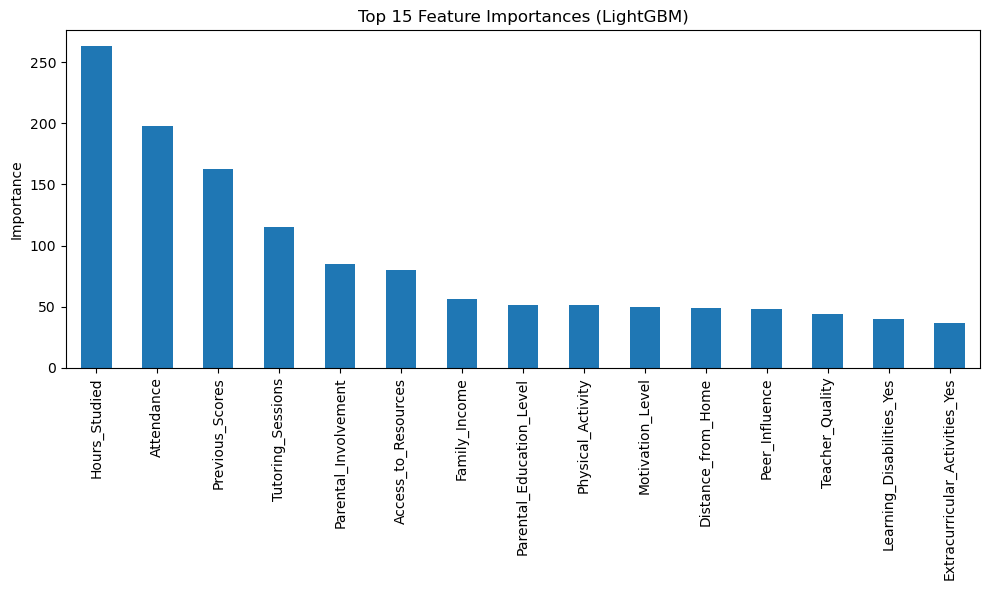

In [43]:
feat_imp = pd.Series(lgb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances (LightGBM)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Final Summary

After testing four models — Linear Regression, Random Forest, XGBoost, and LightGBM — the tuned XGBoost Regressor delivered the best performance, achieving the lowest MAE (0.67) and highest R² score (0.75). LightGBM also performed strongly with an MAE of 0.78 and R² of 0.737, indicating it is a competitive and efficient alternative. Random Forest and Linear Regression were less effective, suggesting that the relationships in the data are non-linear and better captured by gradient boosting methods.

Based on these results, XGBoost is recommended as the final model, with LightGBM as a strong backup option.